In [1]:
# Written for python 3.10.12
# UTF8-encoding
#
# Author: Niels S Hvidberg
# Date: 02-06-2024
# 
# Description: Importing and organising ICOS measuring stations
# as preparation for easy data extraction in DEHM output files.

## Import libraries, often used libraries are included but commented out
import numpy as np
import matplotlib.pyplot as plt
#import icoscp

import seaborn as sb
import pandas as pd
# import xarray as xr
import datetime as dt

sb.set_theme()

# Constants

In [2]:
ll = 76
dehm_height = np.array([11.54187, 38.52108, 73.3263, 116.03519])
nstations = 37 # actually 38, change w. new data
dati = [12, 24, 36, 48, 60, 76]
path = {'envs' : '/home/niels/Documents/Data/ICOS/',
        'dmi' : '/home/niehvi/Documents/Data/ICOS/',
        'dmu' : '/home/nsh/Documents/Data/ICOS/',
        'data' : '/home/niels/Documents/Data/',
       }

# Constructing a Dictionary for all ICOS stations with info

In [3]:
## stations dictionary:
#
# Number of stations: 38
# nstations = 38
# Number of data files: 91
nfile = 91
#
# Description:
# Name: Name of station.
# Code: Short 3 character code for the station.
# Height_ordered: List of measuring heights ordered by station.
# Height: List of measuring heights.
# Country: Country code for the location.
# Measurements: 
# File: File name for the stations data files.
# STR: 3 string components that wraps 'Code' and 'Height'.
#      'ICOS_ATC_L2_L2-2023.1_{stations['Code'][i]}_{stations['Height'][i][j]}_CTS_CO2'
# Path: The path to the Data directory for the ICOS stations data.
#
stat_idx = {'Name': ['Kresin',
                     'Station Nord',
                     'Pallas',
                     'Puijo',
                     'Hyytiala',
                     'Uto',
                     'Observatoire Perenne',
                     'Puy de Dome',
                     'La Reunion',
                     'Saclay',
                     'Trainou',
                     'Gartow',
                     'Helgoland',
                     'Hohenpeissenberg',
                     'Julich',
                     'Karlsruhe',
                     'Lindenberg',
                     'Ochsenkopf',
                     'Schauinsland',
                     'Steinkimmen',
                     'Torfhaus',
                     'Westerland',
                     'Zugspitze',
                     'Monte Cimone',
                     'Ispra',
                     'Lampedusa',
                     'Plateau Rosa',
                     'Cabauw',
                     'Lutjewad',
                     'Birkenes',
                     'Zeppelin',
                     'Izana',
                     'Hyltemossa',
                     'Norunda',
                     'Svartberget',
                     'Jungfraujoch',
                     'Ridge Hill',
                     'Weybourne',
                ],

            'Code': ['KRE',
                     'SNO',
                     'PAL',
                     'PUI',
                     'SMR',
                     'UTO',
                     'OPE',
                     'PUY',
                     'RUN',
                     'SAC',
                     'TRN',
                     'GAT',
                     'HEL',
                     'HPB',
                     'JUE',
                     'KIT',
                     'LIN',
                     'OXK',
                     'SSL',
                     'STE',
                     'TOH',
                     'WES',
                     'ZSF',
                     'CMN',
                     'IPR',
                     'LMP',
                     'PRS',
                     'CBW',
                     'LUT',
                     'BIR',
                     'ZEP',
                     'IZO',
                     'HTM',
                     'NOR',
                     'SVB',
                     'JFJ',
                     'RGL',
                     'WAO',
                ],

            'Height_ordered': [[10.0, 50.0, 125.0, 250.0],
                       	       [20.0, 50.0, 85.0],
                       	       [12.0],
                       	       [47.0,84.0],
                       	       [16.8, 67.2, 125.0],
                       	       [57.0],
                       	       [10.0, 50.0, 120.0],
                       	       [10.0],
                       	       [6.0],
                       	       [15.0, 60.0, 100.0],
                       	       [5.0, 50.0, 100.0, 180.0],
                       	       [30.0, 60.0, 132.0, 216.0, 341.0],
                       	       [110.0],
                       	       [50.0, 93.0, 131.0],
                       	       [50.0, 80.0, 120.0],
                       	       [30.0, 60.0, 100.0, 200.0],
                       	       [2.5, 10.0, 40.0, 98.0],
                       	       [23.0, 90.0, 163.0],
                       	       [12.0, 35.0],
                       	       [32.0, 82.0, 127.0, 187.0, 252.0],
                       	       [10.0, 76.0, 110.0, 147.0],
                       	       [14.0],
                       	       [3.0],
                       	       [8.0],
                       	       [40.0, 60.0, 100.0],
                       	       [8.0],
                       	       [10.0],
                       	       [27.0, 67.0, 127.0, 207.0],
                       	       [60.0],
                       	       [10.0, 50.0, 75.0],
                       	       [15.0],
                       	       [29.0],
                       	       [30.0, 70.0, 150.0],
                       	       [32.0, 58.0, 100.0],
                       	       [35.0, 85.0, 150.0],
                       	       [13.9],
                       	       [45.0, 90.0],
                       	       [10.0],
                ],
            
            'Height': [10.0, 50.0, 125.0, 250.0,
                       20.0, 50.0, 85.0,
                       12.0,
                       47.0,84.0,
                       16.8, 67.2, 125.0,
                       57.0,
                       10.0, 50.0, 120.0,
                       10.0,
                       6.0,
                       15.0, 60.0, 100.0,
                       5.0, 50.0, 100.0, 180.0,
                       30.0, 60.0, 132.0, 216.0, 341.0,
                       110.0,
                       50.0, 93.0, 131.0,
                       50.0, 80.0, 120.0,
                       30.0, 60.0, 100.0, 200.0,
                       2.5, 10.0, 40.0, 98.0,
                       23.0, 90.0, 163.0,
                       12.0, 35.0,
                       32.0, 82.0, 127.0, 187.0, 252.0,
                       10.0, 76.0, 110.0, 147.0,
                       14.0,
                       3.0,
                       8.0,
                       40.0, 60.0, 100.0,
                       8.0,
                       10.0,
                       27.0, 67.0, 127.0, 207.0,
                       60.0,
                       10.0, 50.0, 75.0,
                       15.0,
                       29.0,
                       30.0, 70.0, 150.0,
                       32.0, 58.0, 100.0,
                       35.0, 85.0, 150.0,
                       13.9,
                       45.0, 90.0,
                       10.0,
                ],

            'Country': ['CZ',
                        'DK',
                        'FI', 'FI', 'FI', 'FI',
                        'FR', 'FR', 'FR', 'FR', 'FR',
                        'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE', 'DE',
                        'IT', 'IT', 'IT', 'IT',
                        'NL', 'NL',
                        'NO', 'NO',
                        'ES',
                        'SE', 'SE', 'SE',
                        'CH',
                        'UK', 'UK',
                ],

            'File': ['ICOS_ATC_L2_L2-2023.1_KRE_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KRE_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KRE_125.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KRE_250.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SNO_20.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SNO_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SNO_85.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PAL_12.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PUI_47.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PUI_84.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SMR_16.8_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SMR_67.2_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SMR_125.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_UTO_57.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OPE_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OPE_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OPE_120.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PUY_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_RUN_6.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SAC_15.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SAC_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SAC_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_5.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TRN_180.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_30.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_132.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_216.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_GAT_341.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HEL_110.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HPB_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HPB_93.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HPB_131.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JUE_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JUE_80.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JUE_120.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_30.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_KIT_200.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_2.5_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_40.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LIN_98.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OXK_23.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OXK_90.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_OXK_163.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SSL_12.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SSL_35.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_32.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_82.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_127.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_187.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_STE_252.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_76.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_110.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_TOH_147.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_WES_14.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_ZSF_3.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CMN_8.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IPR_40.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IPR_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IPR_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LMP_8.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_PRS_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_27.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_67.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_127.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_CBW_207.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_LUT_60.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_BIR_10.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_BIR_50.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_BIR_75.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_ZEP_15.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_IZO_29.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HTM_30.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HTM_70.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_HTM_150.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_NOR_32.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_NOR_58.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_NOR_100.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SVB_35.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SVB_85.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_SVB_150.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_JFJ_13.9_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_RGL_45.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_RGL_90.0_CTS.CO2',
                     'ICOS_ATC_L2_L2-2023.1_WAO_10.0_CTS.CO2',
            ],
            
            'STR': ['ICOS_ATC_L2_L2-2023.1_',
                    '_',
                    '_CTS.CO2',
                ],

            'Path_envs' : '/home/niels/Documents/Data/ICOS/',
            'Path_dmi' : '/home/niehvi/Documents/Data/ICOS/',
            'Path_dmu' : '/home/nsh/Documents/Data/ICOS/',

            'Index_stat' : np.arange(nstations),

            'Index' : np.arange(nfile),
    }

# Print counts
print('Name length:', len(stat_idx['Name']))
print('Code length:', len(stat_idx['Code']))
print('Height length:', len(stat_idx['Height']))
print('Country length:', len(stat_idx['Country']))
print('Number of files:', len(stat_idx['File']))

Name length: 38
Code length: 38
Height length: 91
Country length: 38
Number of files: 91


In [4]:
def get_number(ln, fp, lat_lon_alt):
    # open file for reading (default)
    f = open(fp)
    # read the content of the file opened 
    content = f.readlines()[ln]
    # read specific lines from the file 
    num = 1
    out = ''
    if lat_lon_alt == 0:
        st = 12
    elif lat_lon_alt == 1:
        st = 13
    elif lat_lon_alt == 2:
        st = 12
    
    for char in content[st:]:
        if char == ' ':
            num = 0
        if num == 1:
            out += char
    return float(out)
    

In [5]:
stations = {}
pf = 0

def cre_filefunc(cde, string):
    def filefunc(h):
        return string[0]+cde+string[1]+f'{h:2.01f}'+string[2]
    return filefunc

for i in range(len(stat_idx['Name'])-(38-nstations)):     ##### NBNBNBNBNBNBNBNBNBNBNBNNBNBNN!!!!!!!!!!!!!!!!!! -(38-nstations) for when nstations is 37
    filepath = stat_idx['Path_envs']+stat_idx['File'][pf]
    lat = get_number(13, filepath, lat_lon_alt = 0)
    lon = get_number(14, filepath, lat_lon_alt = 1)
    alt = get_number(15, filepath, lat_lon_alt = 2)

    hs = len(stat_idx['Height_ordered'][i])
    stations[stat_idx['Name'][i]] = {'Code' : stat_idx['Code'][i],
                                     'Index' : i,
                                     'FileIndex' : [pf+j for j in range(hs)],
                                     'Height' : stat_idx['Height_ordered'][i],
                                     'Country' : stat_idx['Country'][i],
                                     'Elevation' : alt,
                                     'Location' : [lat, lon],
                                     'File' :  cre_filefunc(stat_idx['Code'][i], stat_idx['STR']),
                                    }
    pf += hs

## Format testing and other stuff

In [6]:
# Longest name: 20
nml = 20
print("Index Name                Code    Lat    Lon    Alt Country")
for station in stations:
    index = f'{stations[station]["Index"] : 5d}'+' '
    name = station+((20-len(station))+1)*' '
    code = (3-len(stations[station]['Code']))*' '+stations[station]['Code']
    lat = f'{stations[station]["Location"][0] : 7.02f}'
    lon = f'{stations[station]["Location"][1] : 7.02f}'
    alt = f'{stations[station]["Elevation"] : 7.0f}'
    ctr = ' '+stations[station]['Country']
    print(index+name+code+lat+lon+alt+ctr)

Index Name                Code    Lat    Lon    Alt Country
    0 Kresin               KRE  49.57  15.08    534 CZ
    1 Station Nord         SNO  81.36 -16.39     24 DK
    2 Pallas               PAL  67.97  24.12    565 FI
    3 Puijo                PUI  62.91  27.65    232 FI
    4 Hyytiala             SMR  61.85  24.29    181 FI
    5 Uto                  UTO  59.78  21.37      8 FI
    6 Observatoire Perenne OPE  48.56   5.50    390 FR
    7 Puy de Dome          PUY  45.77   2.97   1465 FR
    8 La Reunion           RUN -21.08  55.38   2154 FR
    9 Saclay               SAC  48.72   2.14    160 FR
   10 Trainou              TRN  47.96   2.11    131 FR
   11 Gartow               GAT  53.07  11.44     70 DE
   12 Helgoland            HEL  54.18   7.88     43 DE
   13 Hohenpeissenberg     HPB  47.80  11.02    934 DE
   14 Julich               JUE  50.91   6.41     98 DE
   15 Karlsruhe            KIT  49.09   8.42    110 DE
   16 Lindenberg           LIN  52.17  14.12     73 DE
   17

In [7]:
# Format testing
a=-0.3
print(f'formatted number: {a: 13.07f}')
print(f'formatted number: {a+356: 013.07f}')
print(f'formatted number: {+4235.56:013.07f}')
print('formatted number: {:013.07f}'.format(3.09405))

formatted number:    -0.3000000
formatted number:  0355.7000000
formatted number: 04235.5600000
formatted number: 00003.0940500


# DEHM data at ICOS stations

## Set-up and loading files (Hardcoding)

In [8]:
directory = 'dehm_stations_data/'
str1 = 'co2conc01.00h'
str2 = ['','.z2','.z3','.z4']
str3 = '.jan.test'
str4 = ['','.2','.3','.4']
str5 = '.dat'

files = []
for nest in str4:
    for lvl in str2:
        files.append(path['data']+directory+str1+lvl+str3+nest+str5)

print(files[-1])

/home/niels/Documents/Data/dehm_stations_data/co2conc01.00h.z4.jan.test.4.dat


In [9]:
with open(files[0]) as record:
    lines = record.readlines()
    ntime = len(lines)//nstations-1
    dehm_time = np.zeros(ntime, dtype=dt.datetime)
    
    for i in range(ntime):
        line = lines[i*nstations]
        
        year = 2022 # int(line[0:12])
        month = int(line[12:24])
        day = int(line[24:36])
        hour = int(line[36:48])

        dehm_time[i] = dt.datetime(year=year, month=month, day=day, hour=hour)

dehm_stat = np.zeros((4,4,nstations,ntime))
time_idx = 0

for nest in range(4):
    for lvl in range(4):
        with open(files[nest*4+lvl]) as record:
            stat_count = 0
            time_count = 0

            lines = record.readlines()

            for i in range(len(lines)-nstations):
                dehm_stat[nest,lvl,stat_count,time_count] = float(lines[i][60:-1])
                stat_count += 1

                if stat_count == nstations:
                    time_count += 1
                    stat_count = 0

## Plotting

In [10]:
# Subtract the mean to look at anomalies: 
if True:
    dehm_stat = dehm_stat-dehm_stat.mean(axis=1)

In [11]:
for nest in range(4):
    for key in stations:
        fig = plt.figure(figsize=(11,5))
        for lvl in range(4):
            plt.plot(dehm_time, dehm_stat[nest, lvl, stations[key]['Index'], :], label=f'z = {lvl+1}')
            plt.title(f'Nest {nest} for station: {key}')

        plt.legend()
        plt.savefig(f'plots/dehm_stations/{stations[key]["Code"]}_nest{nest}.png')
        plt.close(fig)

# ICOS data

## Set-up and overview (Hardcoding)

In [12]:
dataframe_names = ['Site',
                   'SamplingHeight',
        		   'Year',
                   'Month',
        		   'Day',
                   'Hour',
        		   'Minute',
                   'DecimalDate',
        		   'co2',
                   'Stdev',
        		   'NbPoints',
                   'Flag',
        		   'InstrumentId',
                   'QualityId',
        		   'LTR',
                   'CMR',
        		   'STTB',
                   'QcBias',
        		   'QcBiasUncertainty',
        		   'co2-WithoutSpikes',
        		   'Stdev-WithoutSpikes',
        		   'NbPoints-WithoutSpikes',
        		  ]

In [13]:
# pd.read_csv(stations['Path_dmi']+stations['File'][0], sep=";", header=44, names=dataframe_names).head()
# dt.datetime(year=df['Year'].values[0], month=df['Month'].values[0], day=df['Day'].values[0], hour=df['Hour'].values[0])

## Plotting

In [15]:
# Initiate concentration and time array:
conc_data = np.zeros((91,70000))-999.99
time_data = np.zeros((91,70000), dtype=dt.datetime)-999.99

mask_limit = [0.0, dt.datetime(year=2022, month=1, day=1, hour=0)] # conc, time

file_count = 0

for key in stations:
    plt.figure(stations[key]['Index'], figsize=(12,7))
    plt.title(key+" tracers")
    plt.xlabel("Date Time")
    plt.ylabel("Concentration [ppmv]")
    
    for height in stations[key]['Height']:
        # Import csv with pandas to dataframe
        df = pd.read_csv(path['envs']+stat_idx['File'][file_count], sep=";", header=44, names=dataframe_names)
        
        time_tmp = pd.to_datetime(df.get(['Year', 'Month', 'Day', 'Hour']))
        conc_tmp = df['co2'].values
        size_tmp = conc_tmp.size

        
        time_data[file_count,:size_tmp] = pd.to_datetime(df.get(['Year', 'Month', 'Day', 'Hour']))
        conc_data[file_count,:size_tmp] = df['co2'].values
        
        mask = np.array([True if x > mask_limit[0] and y > mask_limit[1] else False for x,y in zip(conc_tmp,time_tmp) ])

        plt.plot(time_tmp[mask], conc_tmp[mask]-conc_tmp[mask].mean(), label=f"height {height} m")
        
        file_count += 1

    plt.legend(loc="upper right")
    plt.savefig("plots/icos_stations/"+stations[key]['Code']+"_tracers")
    plt.close()

Text(0.5, 1.0, 'Distribution of measuring height for ICOS stations')

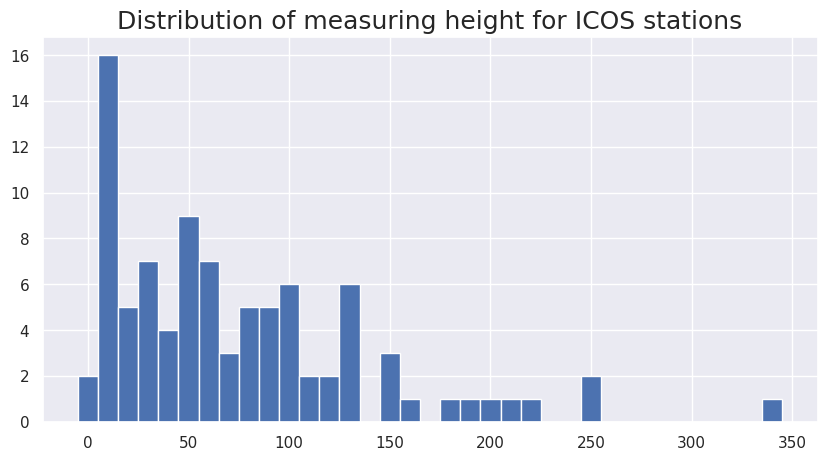

In [16]:
plt.figure(figsize=(10,5))
info = plt.hist(stat_idx['Height'], bins=np.arange(-5,350,10))
plt.title("Distribution of measuring height for ICOS stations", fontsize=18)

# Comparing DEHM stations and measured data

In [23]:
# Initiate concentration and time array:
conc_data = []
time_data = []

mask_limit = [-99.9,
              dt.datetime(year=2022, month=1, day=1, hour=0),
              dt.datetime(year=2022, month=2, day=1, hour=0),
             ] # conc, time_low, time_high

for key in stations:
    plt.figure(stations[key]['Index'], figsize=(12,7))
    plt.title(key+" compared to DEHM")
    plt.xlabel("Date Time")
    plt.ylabel("Concentration [ppmv]")

    height = stations[key]['Height'][0]
    
    case = np.abs(dehm_height-np.array(height)).argmin()
    
    # Import csv with pandas to dataframe
    df = pd.read_csv(path['envs']+stations[key]['File'](stations[key]['Height'][0]), sep=";", header=44, names=dataframe_names)
    
    time_tmp = pd.to_datetime(df.get(['Year', 'Month', 'Day', 'Hour']))
    conc_tmp = df['co2'].values
    size_tmp = conc_tmp.size

    
    time_data.append(pd.to_datetime(df.get(['Year', 'Month', 'Day', 'Hour'])))
    conc_data[stations[key]['Index'],:size_tmp] = df['co2'].values
    
    mask = np.array([True if (mconc > mask_limit[0]) and 
                            ((mask_limit[1] < myear) and (myear < mask_limit[2]))
                     else False
                     for mconc,myear in zip(conc_tmp,time_tmp)
                    ])

    plt.plot(time_tmp[mask], conc_tmp[mask]-conc_tmp[mask].mean(), label=f"ICOS height: {height}m")

    # Find a way to choose the innermost nest for each station    
                               # [nest,  lvl,                   stat, time]
    plt.plot(dehm_time, dehm_stat[   3, case, stations[key]['Index'],    :], label=f'DEHM height: {dehm_height[case]}m')
    plt.title(f'Nest {nest} for station: {key}')

    plt.legend(loc="upper right")
    plt.savefig("plots/icos_stations/"+stations[key]['Code']+"_tracers")
    plt.close()

/tmp/ipykernel_6665/999577611.py:37: RuntimeWarning: Mean of empty slice.
  plt.plot(time_tmp[mask], conc_tmp[mask]-conc_tmp[mask].mean(), label=f"ICOS height: {height}m")
/home/niels/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_6665/999577611.py:37: RuntimeWarning: Mean of empty slice.
  plt.plot(time_tmp[mask], conc_tmp[mask]-conc_tmp[mask].mean(), label=f"ICOS height: {height}m")
/home/niels/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [27]:
len(mask)

18360

In [29]:
size_tmp

18360